# RetainIQ — Churn Patterns: Distributions, Outliers & Segments

Deep-dive extension of `01_eda.ipynb`'s Phase 1 EDA. All analysis logic lives in `src/data/eda.py` and `src/data/load_data.py` — this notebook only calls into them and renders the results.

In [1]:
import sys
from pathlib import Path

# Allow `import src...` when the notebook is run from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display

from src.data.config import FIGURES_DIR
from src.data.load_data import load_clean_data, load_raw_data, missing_total_charges_rows
from src.data.eda import (
    NUMERIC_COLUMNS,
    churn_rate_by_segment,
    distribution_stats,
    summarize_outliers,
    generate_all_figures,
)

pd.set_option("display.max_columns", None)
df = load_clean_data()
raw = load_raw_data()
df.shape

(7043, 20)

Regenerate every KPI chart (including the 3 new outlier boxplots) before rendering any of them below, so the images this notebook displays are always current for whatever `df` was just loaded — not whatever was on disk from a previous run.

In [2]:
paths = generate_all_figures(df)
print(f"Saved {len(paths)} figures to reports/figures/")

Saved 13 figures to reports/figures/


## 1. Distribution analysis

In [3]:
display(distribution_stats(df))

,column,mean,median,std,skew,kurtosis,min,max
0,tenure,32.371149,29.00,24.559481,0.239540,-1.387372,0.00,72.00
1,MonthlyCharges,64.761692,70.35,30.090047,-0.220524,-1.257260,18.25,118.75
2,TotalCharges,2279.734304,1394.55,2266.794470,0.963235,-0.228580,0.00,8684.80


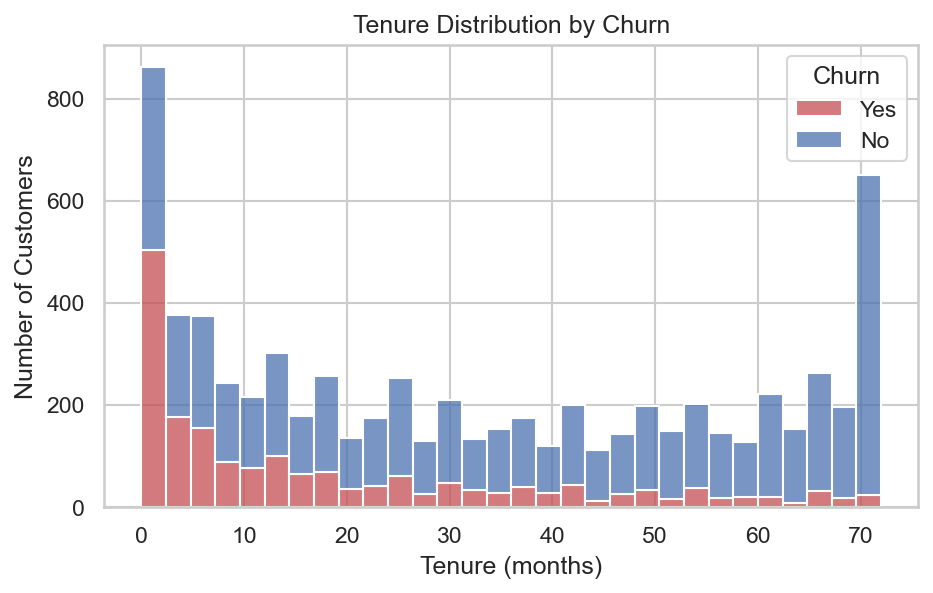

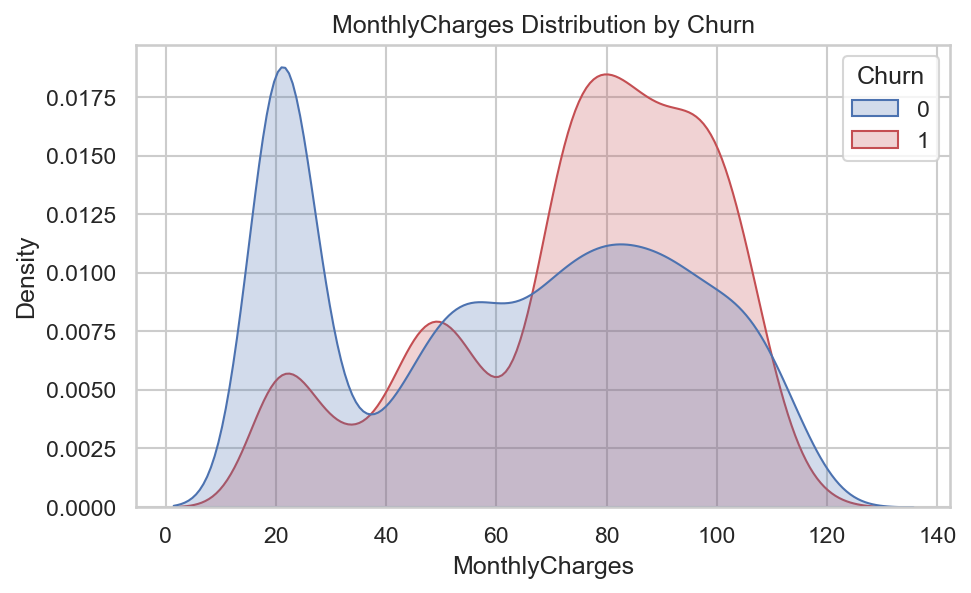

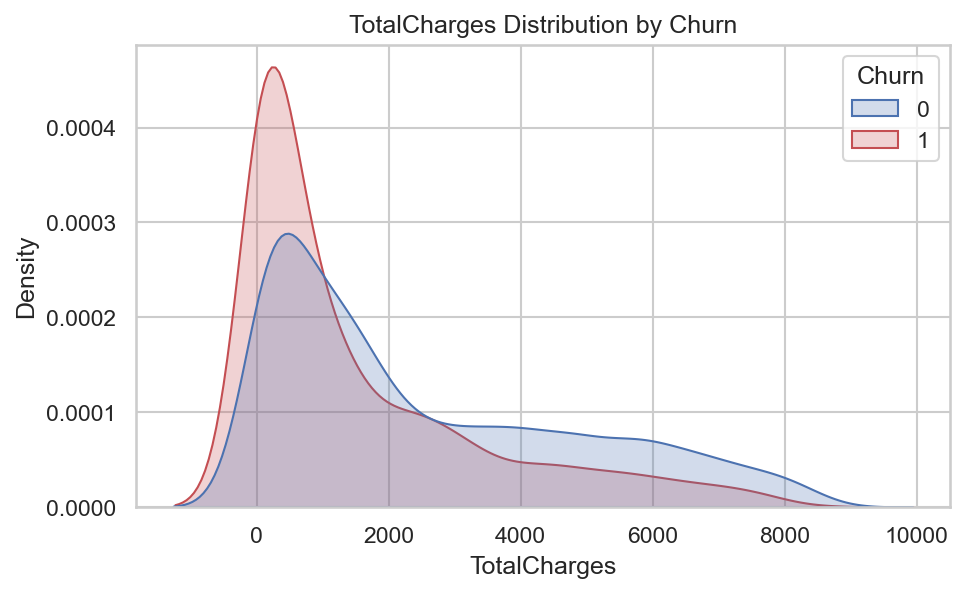

In [4]:
for col in NUMERIC_COLUMNS:
    display(Image(str(FIGURES_DIR / f"{col.lower()}_distribution.png")))

`TotalCharges` is the most skewed of the three (skew ≈ 0.96 — moderately right-skewed), consistent with most customers paying modest monthly amounts and a long tail of high-tenure, high-total-spend customers. `tenure` (skew ≈ 0.24) and `MonthlyCharges` (skew ≈ -0.22) are close to symmetric. This is informational for Phase 2's feature pipeline — a log-transform of `TotalCharges` could help a linear baseline; tree-based models (XGBoost/LightGBM) don't need it.

## 2. The 11 missing TotalCharges values

In [5]:
missing = missing_total_charges_rows(raw)[["tenure", "Contract", "MonthlyCharges", "TotalCharges", "Churn"]]
display(missing)
print("All tenure == 0:", (missing["tenure"] == 0).all())
print(missing["Contract"].value_counts())
print(missing["Churn"].value_counts())

,tenure,Contract,MonthlyCharges,TotalCharges,Churn
488,0,Two year,52.55,,No
753,0,Two year,20.25,,No
936,0,Two year,80.85,,No
1082,0,Two year,25.75,,No
1340,0,Two year,56.05,,No
3331,0,Two year,19.85,,No
3826,0,Two year,25.35,,No
4380,0,Two year,20.00,,No
5218,0,One year,19.70,,No
6670,0,Two year,73.35,,No


All tenure == 0: True
Contract
Two year    10
One year     1
Name: count, dtype: int64
Churn
No    11
Name: count, dtype: int64


All 11 rows are brand-new signups: `tenure == 0` for every one of them, so no billing cycle has completed yet and `TotalCharges` is genuinely unset rather than corrupted. All 11 are on **One-year or Two-year contracts** (10 Two-year, 1 One-year — none month-to-month), and all 11 currently have `Churn == "No"`. `clean_data()` (`src/data/load_data.py`) imputes these rows to `0`, which is defensible for exactly this reason: a customer billed for zero months has accumulated zero charges.

## 3. Outlier analysis

In [6]:
display(summarize_outliers(df))

,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
0,tenure,9.00,55.00,46.00,-60.000,124.000,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.025,171.375,0,0.0
2,TotalCharges,398.55,3786.60,3388.05,-4683.525,8868.675,0,0.0


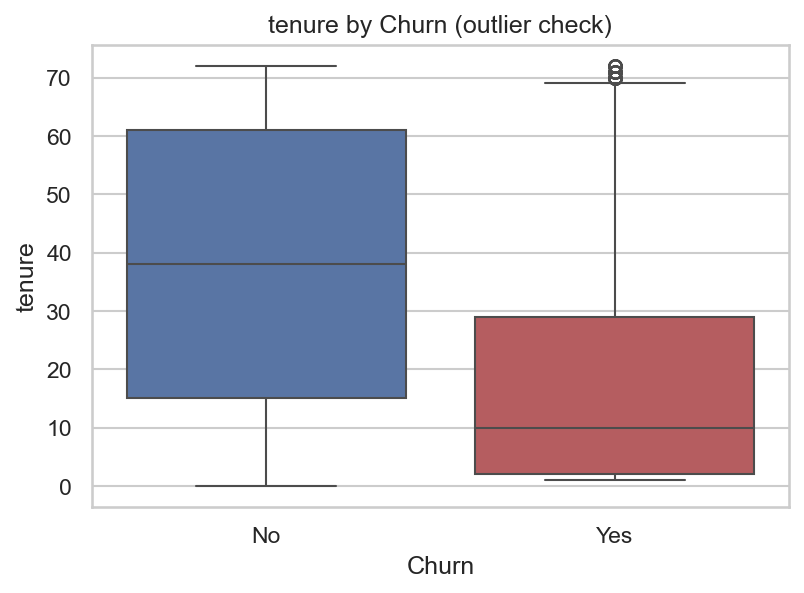

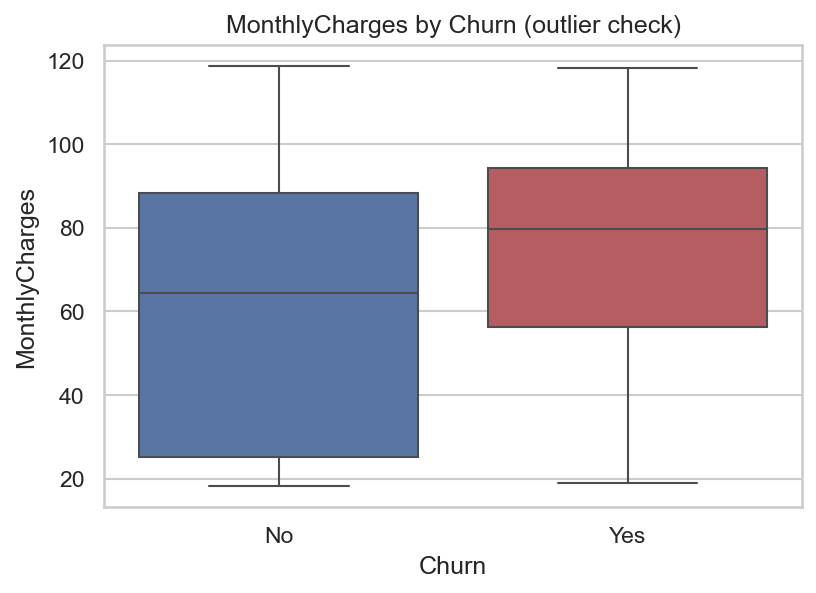

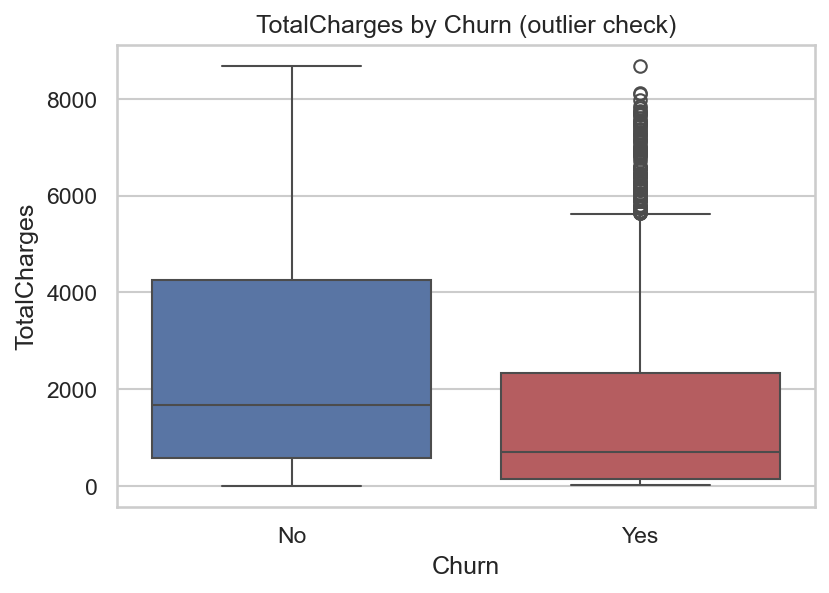

In [7]:
for col in NUMERIC_COLUMNS:
    display(Image(str(FIGURES_DIR / f"{col.lower()}_boxplot.png")))

Using the standard Tukey IQR fence (`Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`), **zero outliers** are found in `tenure`, `MonthlyCharges`, or `TotalCharges`. This is plausible for this dataset: all three fields are naturally bounded (tenure can't be negative or exceed the observation window; charges can't be negative) with no data-entry anomalies to clean. No outlier treatment (capping/removal) is applied — that decision is deferred to Phase 2's feature pipeline if a specific model needs it.

## 4. Churn rate by Contract / InternetService / PaymentMethod

Churn rate by Contract:


,Contract,churn_rate,customers
0,Month-to-month,42.71,3875
1,One year,11.27,1473
2,Two year,2.83,1695


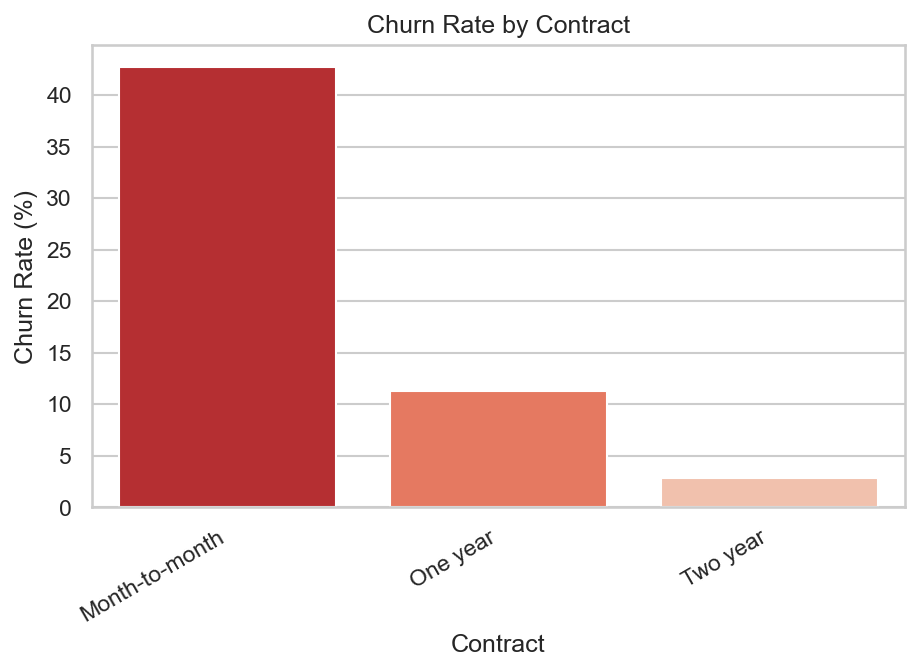

Churn rate by InternetService:


,InternetService,churn_rate,customers
0,Fiber optic,41.89,3096
1,DSL,18.96,2421
2,No,7.40,1526


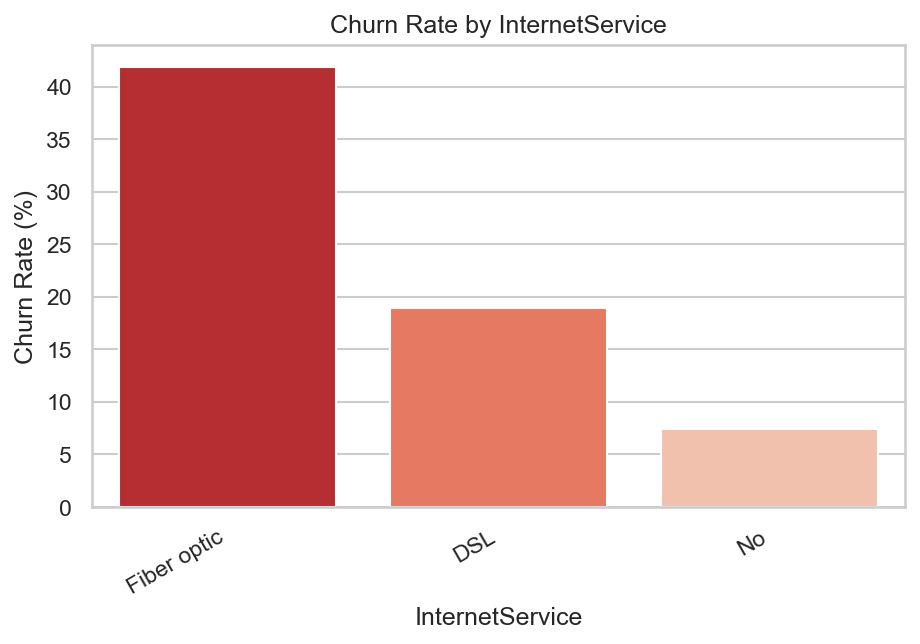

Churn rate by PaymentMethod:


,PaymentMethod,churn_rate,customers
0,Electronic check,45.29,2365
1,Mailed check,19.11,1612
2,Bank transfer (automatic),16.71,1544
3,Credit card (automatic),15.24,1522


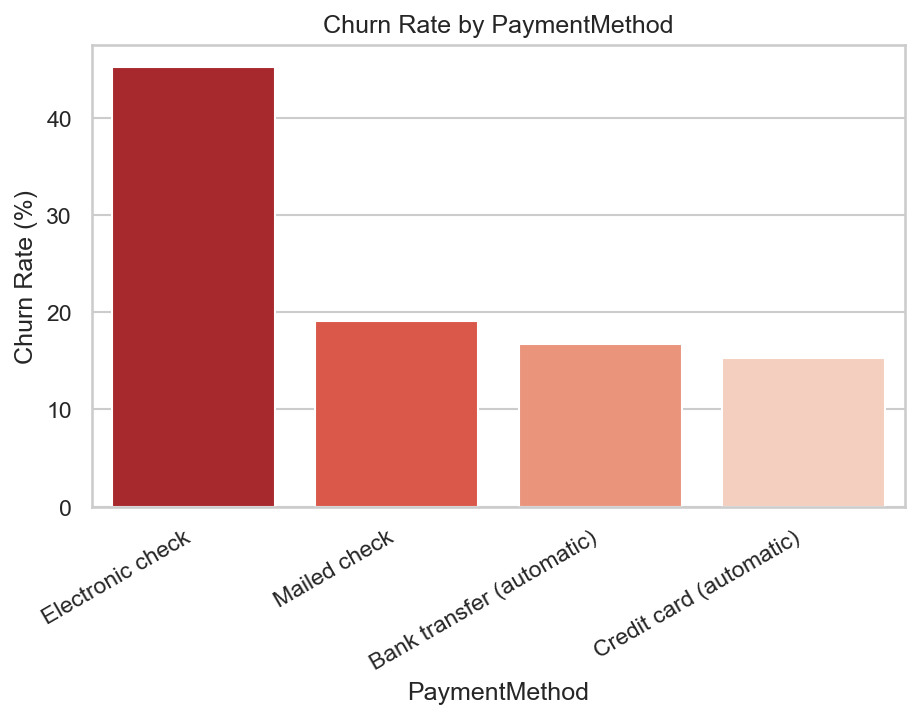

In [8]:
for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"Churn rate by {col}:")
    display(churn_rate_by_segment(df, col))
    display(Image(str(FIGURES_DIR / f"churn_rate_by_{col}.png")))

## Key findings

- **`TotalCharges` is moderately right-skewed** (skew ≈ 0.96); `tenure` and `MonthlyCharges` are close to symmetric. Relevant to Phase 2's feature pipeline, not acted on here.
- **Zero IQR outliers** in `tenure`, `MonthlyCharges`, or `TotalCharges` — the billing/tenure fields are naturally bounded, so there's nothing to clean or cap.
- **The 11 missing `TotalCharges` rows** are all brand-new signups (`tenure == 0`) on One/Two-year contracts, all still retained — imputing them to 0 (done in `clean_data()`) is the correct call, not a workaround.
- **Contract is the strongest segment driver**: month-to-month churns ~42.7% vs. ~11.3% (one-year) vs. ~2.8% (two-year).
- **Electronic check payers** churn ~45.3% and **fiber-optic** internet customers churn ~41.9% — both substantially above the 26.5% base rate, consistent with CLAUDE.md §6's expected signals.